<a href="https://colab.research.google.com/github/tauqeer-jetcom/ML_PROJECTS_1-61023748031/blob/main/KNN_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

data = pd.read_csv("teleCust1000t.csv")
data

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,10,39,0,0,27.0,3,0,0.0,1,3,1
996,1,7,34,0,2,22.0,5,5,0.0,1,1,1
997,3,67,59,0,40,944.0,5,33,0.0,1,1,4
998,3,70,49,0,18,87.0,2,22,0.0,1,1,3


In [3]:
data.size
data.columns

Index(['region', 'tenure', 'age', 'marital', 'address', 'income', 'ed',
       'employ', 'retire', 'gender', 'reside', 'custcat'],
      dtype='object')

In [4]:
data.describe()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
count,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.0220,35.526000,41.684000,0.495000,11.551000,77.535000,2.671000,10.987000,0.047000,0.517000,2.331000,2.487000
std,0.8162,21.359812,12.558816,0.500225,10.086681,107.044165,1.222397,10.082087,0.211745,0.499961,1.435793,1.120306
min,1.0000,1.000000,18.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.0000,17.000000,32.000000,0.000000,3.000000,29.000000,2.000000,3.000000,0.000000,0.000000,1.000000,1.000000
50%,2.0000,34.000000,40.000000,0.000000,9.000000,47.000000,3.000000,8.000000,0.000000,1.000000,2.000000,3.000000
75%,3.0000,54.000000,51.000000,1.000000,18.000000,83.000000,4.000000,17.000000,0.000000,1.000000,3.000000,3.000000
max,3.0000,72.000000,77.000000,1.000000,55.000000,1668.000000,5.000000,47.000000,1.000000,1.000000,8.000000,4.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   region   1000 non-null   int64  
 1   tenure   1000 non-null   int64  
 2   age      1000 non-null   int64  
 3   marital  1000 non-null   int64  
 4   address  1000 non-null   int64  
 5   income   1000 non-null   float64
 6   ed       1000 non-null   int64  
 7   employ   1000 non-null   int64  
 8   retire   1000 non-null   float64
 9   gender   1000 non-null   int64  
 10  reside   1000 non-null   int64  
 11  custcat  1000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 93.9 KB


In [6]:
data.isnull().sum()

,0
region,0
tenure,0
age,0
marital,0
address,0
income,0
ed,0
employ,0
retire,0
gender,0


In [8]:
data['custcat'].value_counts()

,count
custcat,
3,281
1,266
4,236
2,217


### Data Visualization (Pre-Feature Engineering)

Before proceeding with feature engineering, let's visualize some key aspects of our cleaned dataset to understand its distribution and potential patterns. We'll examine the distribution of the target variable (`custcat`) and a couple of numerical features (`age` and `income`).

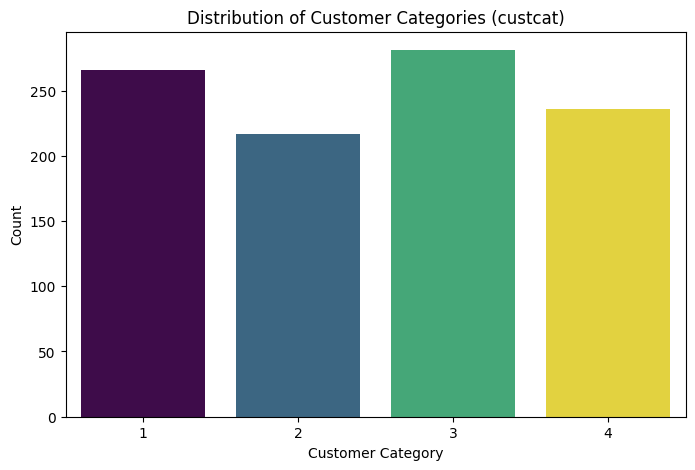

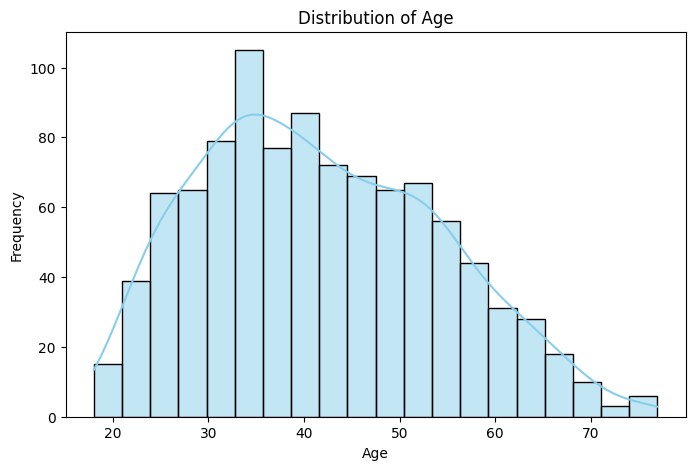

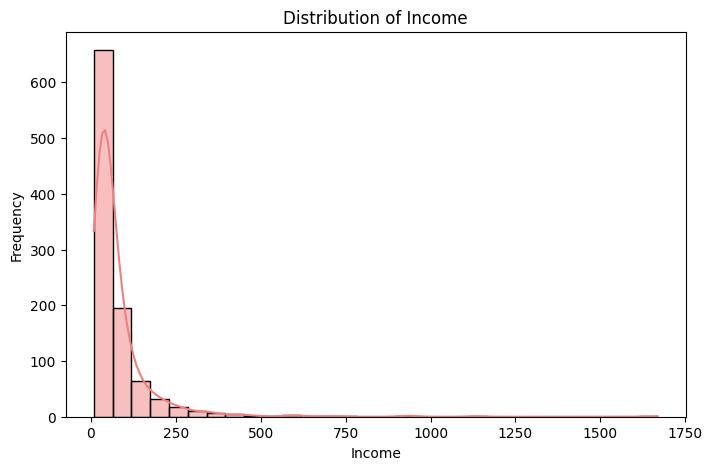

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable 'custcat'
plt.figure(figsize=(8, 5))
sns.countplot(x='custcat', data=data, palette='viridis', hue='custcat', legend=False)
plt.title('Distribution of Customer Categories (custcat)')
plt.xlabel('Customer Category')
plt.ylabel('Count')
plt.show()

# Visualize the distribution of 'age'
plt.figure(figsize=(8, 5))
sns.histplot(data['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Visualize the distribution of 'income'
plt.figure(figsize=(8, 5))
sns.histplot(data['income'], bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

## Feature Engineering

Based on the initial data exploration, the dataset appears clean in terms of missing values and data types. However, for machine learning models, especially distance-based ones like K-Nearest Neighbors, feature engineering steps such as feature scaling and handling categorical variables are often crucial.

I will proceed with the following steps:
1.  **Separate Features (X) and Target (y):** The `custcat` column appears to be the target variable, representing customer categories.
2.  **Feature Scaling:** Scale the numerical features using `StandardScaler` to ensure all features contribute equally to distance calculations.


In [10]:
from sklearn import preprocessing

X = data[['region', 'tenure','age', 'marital', 'address', 'income', 'ed', 'employ','retire', 'gender', 'reside']] .values  #.astype(float)
y = data['custcat'].values

print("First 5 rows of X:")
print(X[0:5])

print("\nFirst 5 rows of y:")
print(y[0:5])

First 5 rows of X:
[[  2.  13.  44.   1.   9.  64.   4.   5.   0.   0.   2.]
 [  3.  11.  33.   1.   7. 136.   5.   5.   0.   0.   6.]
 [  3.  68.  52.   1.  24. 116.   1.  29.   0.   1.   2.]
 [  2.  33.  33.   0.  12.  33.   2.   0.   0.   1.   1.]
 [  2.  23.  30.   1.   9.  30.   1.   2.   0.   0.   4.]]

First 5 rows of y:
[1 4 3 1 3]


### Normalize Data

Data Standardization (or normalization) gives the data zero mean and unit variance. This is often a good practice, especially for algorithms like K-Nearest Neighbors which rely on distance metrics.

In [11]:
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))

# Display the first 5 rows of the scaled features
print("First 5 rows of scaled features (X) after standardization:")
print(X[0:5])

First 5 rows of scaled features (X) after standardization:
[[-0.02696767 -1.055125    0.18450456  1.0100505  -0.25303431 -0.12650641
   1.0877526  -0.5941226  -0.22207644 -1.03459817 -0.23065004]
 [ 1.19883553 -1.14880563 -0.69181243  1.0100505  -0.4514148   0.54644972
   1.9062271  -0.5941226  -0.22207644 -1.03459817  2.55666158]
 [ 1.19883553  1.52109247  0.82182601  1.0100505   1.23481934  0.35951747
  -1.36767088  1.78752803 -0.22207644  0.96655883 -0.23065004]
 [-0.02696767 -0.11831864 -0.69181243 -0.9900495   0.04453642 -0.41625141
  -0.54919639 -1.09029981 -0.22207644  0.96655883 -0.92747794]
 [-0.02696767 -0.58672182 -0.93080797  1.0100505  -0.25303431 -0.44429125
  -1.36767088 -0.89182893 -0.22207644 -1.03459817  1.16300577]]


### Train Test Split

To evaluate the model's performance on unseen data, we'll split the dataset into training and testing sets. A common split is 80% for training and 20% for testing.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)

print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)



Train set: (800, 11) (800,)
Test set: (200, 11) (200,)


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=38)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_train = model.predict(X_train)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred)

print(f"Train set Accuracy: {accuracy_train}")
print(f"Test set Accuracy: {accuracy_test}")


Train set Accuracy: 0.4275
Test set Accuracy: 0.41


### Visualizing Accuracy for Different K Values

To find the optimal 'k' for the K-Nearest Neighbors algorithm, we'll calculate the accuracy for a range of 'k' values and visualize how the accuracy changes.

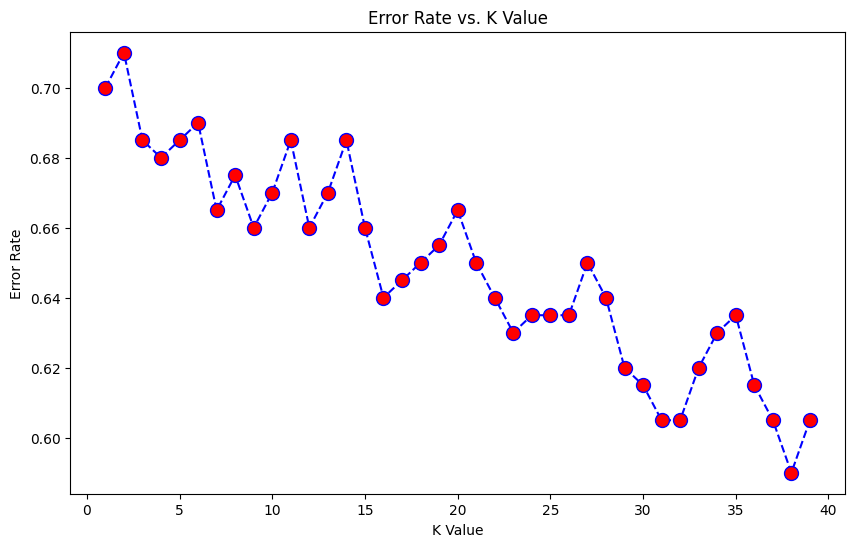

In [18]:
error_rate = []
# Try k from 1 to 40
for i in range(1,40):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    pred_i = model.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting the error rate vs. K value
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()

The minimum error rate is 0.5900 at K = 38


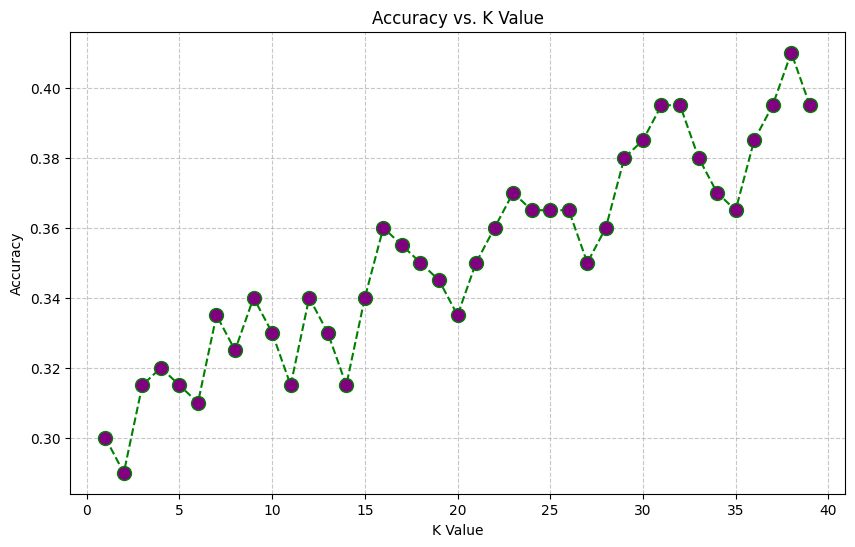

In [19]:
# Based on the error rate plot, we can find the K value with the minimum error rate.
# Let's find the K value with the minimum error rate.
min_error = min(error_rate)
optimal_k = error_rate.index(min_error) + 1 # +1 because range starts from 1

print(f"The minimum error rate is {min_error:.4f} at K = {optimal_k}")

# Now, let's plot the accuracy for different K values
accuracy_rates = [1 - err for err in error_rate]

plt.figure(figsize=(10,6))
plt.plot(range(1,40),accuracy_rates,color='green', linestyle='dashed', marker='o',
         markerfacecolor='purple', markersize=10)
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The plots above show how the error rate and accuracy change as the number of neighbors (`K`) in the KNN model varies. This helps in selecting an optimal `K` value where the model performs best on the test set.